### Load and encode data

In [33]:
import zipfile
import pandas as pd
from sklearn.preprocessing import LabelEncoder

zip_path = "../data_processed.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    X_train_std = pd.read_csv(z.open('X_train_std.csv'))
    Y_train = pd.read_csv(z.open('Y_train.csv'))
    X_test_std  = pd.read_csv(z.open('X_test_std.csv'))
    Y_test  = pd.read_csv(z.open('Y_test.csv'))

unique_values = Y_train['diabetes_stage'].unique()
print("Unique values:", unique_values)
print(Y_train['diabetes_stage'].value_counts())

zip_path = "../data_processed_unstanderdized.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    X_train = pd.read_csv(z.open('X_train.csv'))
    X_test  = pd.read_csv(z.open('X_test.csv'))

# Identify categorical columns (dtype == object)
categorical_cols = X_train_std.select_dtypes(include=['object']).columns

# Apply one-hot encoding only to categorical columns
X_train_std_encoded = pd.get_dummies(X_train_std, columns=categorical_cols, drop_first=True)
X_test_std_encoded = pd.get_dummies(X_test_std, columns=categorical_cols, drop_first=True)
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure train and test have the same columns
X_test_std_encoded = X_test_std_encoded.reindex(columns=X_train_std_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

le = LabelEncoder()

# Fit on training labels and transform both train/test
Y_train_encoded = le.fit_transform(Y_train.values.ravel())
Y_test_encoded = le.transform(Y_test.values.ravel())

Unique values: ['Type 2' 'Pre-Diabetes' 'No Diabetes' 'Gestational' 'Type 1']
diabetes_stage
Type 2          44916
Pre-Diabetes    23740
No Diabetes      6044
Gestational       209
Type 1             91
Name: count, dtype: int64


### Helper functions for running grid search

In [39]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay


def run_grid_search_classification(model_pipeline, param_grid, X_train, y_train, X_test, y_test, cv=5, scoring='f1_weighted'):
    """
    Runs grid search using given model pipeline and param_grid 
    """
    start_time = time.time()

    # Convert y_train to 1D if needed
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.iloc[:, 0]

    # Grid Search
    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=True,
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    cv_results = grid_search.cv_results_
    best_index = grid_search.best_index_
    mean_cv_f1 = cv_results['mean_test_score'][best_index]
    std_cv_f1 = cv_results['std_test_score'][best_index]

    # Compute CV accuracy for the best model separately
    cv_accuracy_scores = cross_val_score(
        best_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1
    )
    mean_cv_acc = cv_accuracy_scores.mean()
    std_cv_acc = cv_accuracy_scores.std()

    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

    if "feature_select" in best_model.named_steps or "select" in best_model.named_steps:
        if "feature_select" in best_model.named_steps:
            selector = best_model.named_steps["feature_select"]
        if "select" in best_model.named_steps:
            selector = best_model.named_steps["select"]
        
        mask = selector.get_support()

        selected_features = X_train.columns[mask]
        print("\n==============================")
        print(f"{len(selected_features)} Selected Features in the best model:")
        for f in selected_features:
            print(f)
        print("==============================\n")

    # CV results
    print("\nClassification report on test set:\n")
    print(classification_report(y_test, y_test_pred, zero_division=0))
    print("Best params:", best_params)
    print(f"CV weighted F1: {mean_cv_f1:.4f} ± {std_cv_f1:.4f}")
    print(f"CV accuracy: {mean_cv_acc:.4f} ± {std_cv_acc:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test weighted F1: {test_f1_weighted:.4f}")

    elapsed_time = time.time() - start_time
    print(f"Elapsed time: {elapsed_time:.2f} s")

    return best_model, best_params


def plot_confusion_matrix(model, X_test, y_test, labels=None, title="Confusion Matrix"):
    """
    Plots a confusion matrix for trained models.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", xticks_rotation="vertical")
    disp.ax_.set_title(title)


def plot_roc_curves(model, X_test, y_test, class_names=None, title="ROC Curves"):
    """
    Plots ROC Curves for SVM or Bayes
    """
    classes = np.unique(y_test)

    # Convert class_names (if ndarray) into list
    if isinstance(class_names, np.ndarray):
        class_names = class_names.tolist()

    # Binarize labels for multi-class ROC
    y_test_bin = label_binarize(y_test, classes=classes)

    # Get model decision scores or predicted probabilities
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        raise ValueError("Model must have predict_proba or decision_function")

    plt.figure(figsize=(10, 8))

    # Plot ROC curve for each class
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        name = class_names[i] if class_names is not None else f"Class {classes[i]}"

        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

    # Baseline
    plt.plot([0, 1], [0, 1], "k--")

    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()



### Run grid search for SVM and get results

In [25]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline

# Base SVM pipeline
pipe_svm = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_classif)),
    ('svc', SVC(class_weight='balanced'))
])

# Grid to search over top-k features + SVM hyperparameters
param_grid_svm = {
    'select__k': [10, 20, 30],
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto']
}

# Run your grid search
best_svm, best_params_svm = run_grid_search_classification(
    pipe_svm, param_grid_svm, 
    X_train_std_encoded, Y_train_encoded, 
    X_test_std_encoded, Y_test_encoded
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

30 Selected Features in the best model:
age
alcohol_consumption_per_week
physical_activity_minutes_per_week
diet_score
sleep_hours_per_day
bmi
waist_to_hip_ratio
systolic_bp
diastolic_bp
heart_rate
cholesterol_total
ldl_cholesterol
triglycerides
glucose_postprandial
insulin_level
family_history_diabetes
hypertension_history
gender_Male
ethnicity_Other
ethnicity_White
education_level_Highschool
education_level_No formal
education_level_Postgraduate
income_level_Lower-Middle
income_level_Middle
income_level_Upper-Middle
employment_status_Retired
employment_status_Unemployed
smoking_status_Former
smoking_status_Never


Classification report on test set:

              precision    recall  f1-score   support

           0       0.00      0.01      0.01        69
           1       0.39      0.79      0.53      1937
           2       0.60      0.67      0.63      8105
           3       0.00      0.00      0.00        31
      

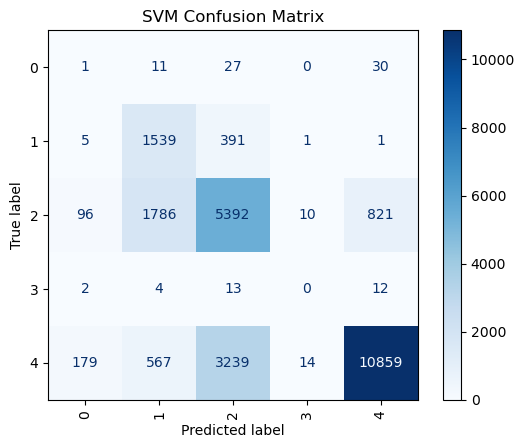

In [26]:
plot_confusion_matrix(best_svm, X_test_std_encoded, Y_test_encoded, labels=best_svm.classes_, title="SVM Confusion Matrix")

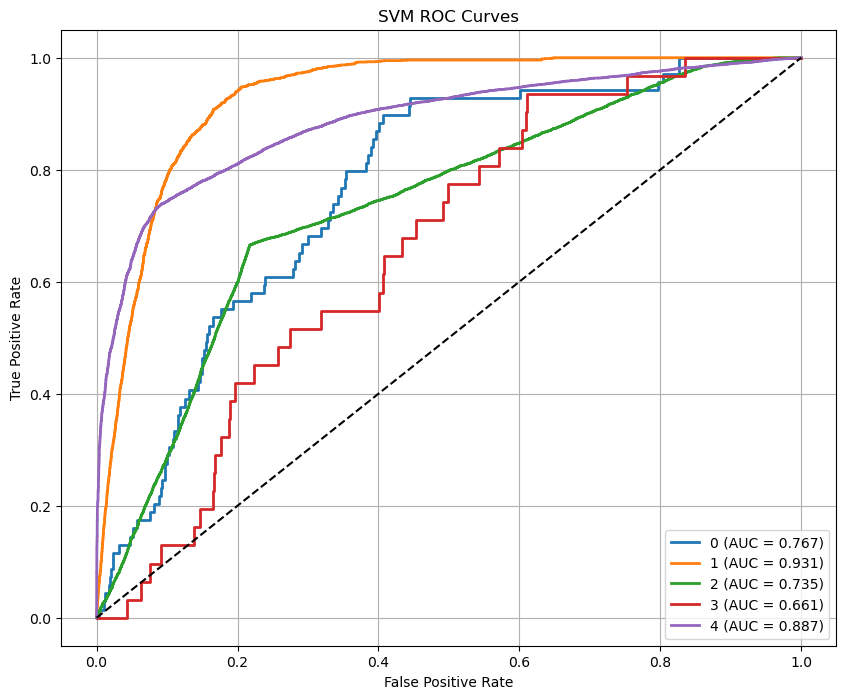

In [40]:
plot_roc_curves(best_svm, X_test_std_encoded, Y_test_encoded, class_names=best_svm.classes_, title="SVM ROC Curves")

### Run grid search for Naive Bayes and get results

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

# Base NB model
nb = GaussianNB()

# Pipeline with forward selection
pipe_nb = Pipeline([
    ('feature_select', SequentialFeatureSelector(
        nb,
        direction='forward',
        scoring='f1_weighted',
        cv=3,
        n_jobs=-1
    )),
    ('nb', nb)
])

# Hyperparameters to search for NB
param_grid_nb = {
    'feature_select__n_features_to_select': [10, 20, 30],
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# Run your grid search function
best_nb, best_params_nb = run_grid_search_classification(
    pipe_nb, param_grid_nb,
    X_train_encoded, Y_train_encoded,
    X_test_encoded, Y_test_encoded
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

20 Selected Features in the best model:
age
alcohol_consumption_per_week
sleep_hours_per_day
screen_time_hours_per_day
bmi
heart_rate
glucose_postprandial
ethnicity_Black
ethnicity_Hispanic
ethnicity_White
education_level_Highschool
education_level_Postgraduate
income_level_Low
income_level_Lower-Middle
income_level_Middle
income_level_Upper-Middle
employment_status_Retired
employment_status_Unemployed
smoking_status_Former
smoking_status_Never


Classification report on test set:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.53      0.44      0.48      1937
           2       0.63      0.67      0.65      8105
           3       0.00      0.00      0.00        31
           4       0.85      0.85      0.85     14858

    accuracy                           0.75     25000
   macro avg       0.40      0.39      0.39     25000
weighted avg     

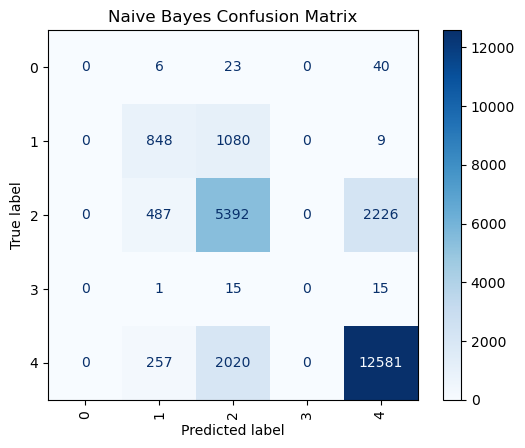

In [37]:
plot_confusion_matrix(best_nb, X_test_encoded, Y_test_encoded, labels=best_nb.classes_, title="Naive Bayes Confusion Matrix")

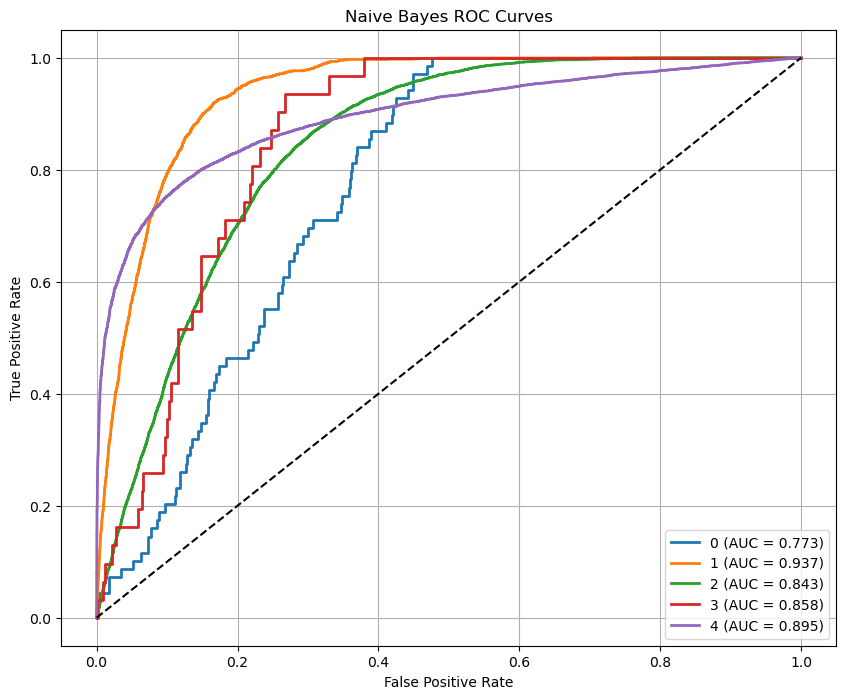

In [41]:
plot_roc_curves(best_nb, X_test_encoded, Y_test_encoded, class_names=best_nb.classes_, title="Naive Bayes ROC Curves")